<a href="https://colab.research.google.com/github/UMB200/AI_ML_pytorch_projects/blob/main/09_pytorch_model_deployment_exercises_Ex7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises, Exercise 7
Exercise is too big, so moved to separate notebook



### 1.0 Get various imports and helper functions


In [1]:
import torch, torchvision, os, zipfile, random, requests, sys, pathlib
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from timeit import default_timer as timer
import tqdm.auto as tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from typing import List, Dict, Tuple
import pandas as pd
import gradio as gr
import shutil
from IPython.display import IFrame
from torch.utils.data import random_split
from collections import Counter


try:
  from torchinfo import summary
except:
  print("No torchinfo found, downloading")
  !pip install -q torchinfo
  from torchinfo import summary

if not os.path.exists('/content/helpers'):
  os.makedirs('/content/helpers')
  sys.path.insert(0, '/content/helpers')
helpers = Path('/content/helpers')

try:
  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit
except:
  print(f"No helper scripts are found, downloading")
  !git clone https://github.com/UMB200/AI_ML_pytorch_projects.git
  !mv /content/AI_ML_pytorch_projects/helpers/* /content/helpers
  print(f"Removing extra stuff from: {helpers}")
  !rm -rf /content/AI_ML_pytorch_projects

  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit


No torchinfo found, downloading
No helper scripts are found, downloading
Cloning into 'AI_ML_pytorch_projects'...
remote: Enumerating objects: 611, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 611 (delta 185), reused 130 (delta 130), pack-reused 410 (from 2)
Receiving objects: 100% (611/611), 46.71 MiB | 18.86 MiB/s, done.
Resolving deltas: 100% (332/332), done.
Removing extra stuff from: /content/helpers


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
#!rm helpers -rf

## Exercise 7. Pick any dataset from [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) and train a feature extractor model on it using a model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) (you could use one of the model's we've already created, e.g. EffNetB2 or ViT) for 5 epochs and then deploy your model as a Gradio app to Hugging Face Spaces.
* You may want to pick smaller dataset/make a smaller split of it so training doesn't take too long.
* I'd love to see your deployed models! So be sure to share them in Discord or on the [course GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions).

### 7.1 Setup model

In [4]:
#%%writefile demo/flower_classifier/model.py
import torch
import torchvision
from torch import nn

def effnetb2_model_create(num_class:int=3, seed:int=42):
  """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model.
        transforms (torchvision.transforms): EffNetB2 image transforms.
  """

  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  for param in model.parameters():
    param.requires_grad = False

  torch.manual_seed(seed)

  model.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True),
                                    nn.Linear(in_features=1408, out_features=num_class, bias=True))
  return model, transforms

In [5]:
NUM_CLASSES_FLOWER = 102

In [6]:
effnetb2_flower_model, effnetb2_transform = effnetb2_model_create(num_class=NUM_CLASSES_FLOWER)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 134MB/s]


### 7.2 Get Data

In [7]:
# Get data
data_dir_flower = Path("data")

# Setup training data
all_data_train = datasets.Flowers102(
    root=data_dir_flower,
    split="train",
    transform=effnetb2_transform,
    download=True
)

all_data_test = datasets.Flowers102(
    root=data_dir_flower,
    split="test",
    transform=effnetb2_transform,
    download=True
)

flower_names = all_data_train.classes

100%|██████████| 345M/345M [00:14<00:00, 24.5MB/s]
100%|██████████| 502/502 [00:00<00:00, 2.12MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 31.8MB/s]


### 7.3 Create DataLoaders

In [8]:
NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32

train_dataloader_flower = torch.utils.data.DataLoader(
    dataset = all_data_train,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_dataloader_flower = torch.utils.data.DataLoader(
    dataset = all_data_test,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

### 7.4 Train Model

In [9]:
# Training data transforms for data augmentation
flower_train_transform = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(), effnetb2_transform])

In [11]:
optimizer_adam = torch.optim.Adam(params=effnetb2_flower_model.parameters(), lr=1e-3)
loss_fn_cross_entrophy = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

effnetb2_flower_model.to(device)
start_time = timer()
effnetb2_flower_output = engine.train(
    model=effnetb2_flower_model,
    train_dataloader = train_dataloader_flower,
    test_dataloader = test_dataloader_flower,
    optimizer=optimizer_adam,
    loss_fn=loss_fn_cross_entrophy,
    epochs=5,
    device=device
)
end_time = timer()
print(f"Total training time: {end_time-start_time:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.3766 | train_acc: 0.1493 | test_loss: 3.7957 | test_acc: 0.6108
Epoch: 2 | train_loss: 3.1725 | train_acc: 0.8076 | test_loss: 3.0842 | test_acc: 0.7537
Epoch: 3 | train_loss: 2.3912 | train_acc: 0.9277 | test_loss: 2.5948 | test_acc: 0.7983
Epoch: 4 | train_loss: 1.8414 | train_acc: 0.9646 | test_loss: 2.2710 | test_acc: 0.8177
Epoch: 5 | train_loss: 1.5362 | train_acc: 0.9763 | test_loss: 2.0515 | test_acc: 0.8316
Total training time: 323.21 seconds


### 7.6 Inspect loss curves of Flower model

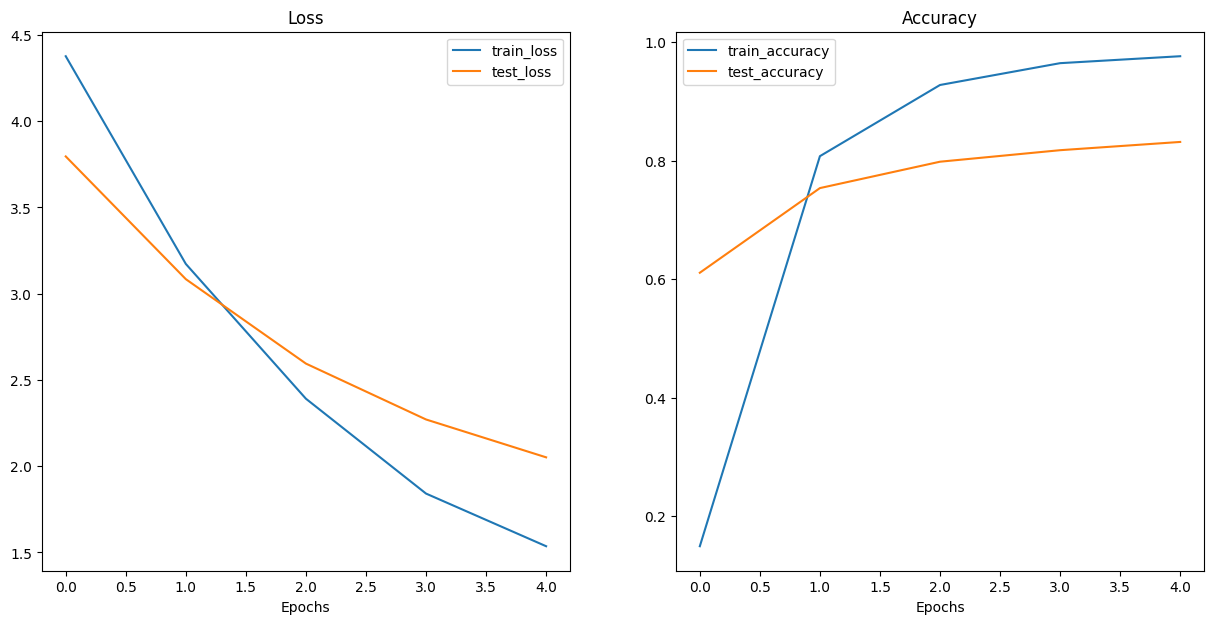

In [12]:
utils.plot_loss_curves(effnetb2_flower_output)

### 7.7 Save and Load Flower model

In [13]:
effnetb2_flower_model_name = "09_pretrained_effnetb2_flower.pth"
utils.save_model(
    model=effnetb2_flower_model,
    target_dir="models",
    model_name=effnetb2_flower_model_name)

[INFO] Saving model to: models/09_pretrained_effnetb2_flower.pth


In [14]:
loaded_effnetb2_flower_model, effenetb2_transform = effnetb2_model_create(num_class=len(all_data_train.classes))
loaded_effnetb2_flower_model.load_state_dict(torch.load("models/09_pretrained_effnetb2_flower.pth"))

<All keys matched successfully>

### 7.8 Check Flower model size

In [15]:
effnetb2_flower_model_size = utils.model_size(Path("models/" +effnetb2_flower_model_name))

Model size at:models/09_pretrained_effnetb2_flower.pth is 30.37 MB


### 7.5 Create Folder structure

```
#File structure for Flower deplopyment
└── flower/
    ├── 09_pretrained_effnetb2_flower_model.pth
    ├── app.py
    ├── class_names.txt
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt```

### 7.6 Creating path for app and moving model & getting examples for model

In [16]:
# Create Flower Classifier demo path
flower_classifier_path = Path("demo/flower_classifier")

# Delete files that already exist
if flower_classifier_path.exists():
  shutil.rmtree(flower_classifier_path)
flower_classifier_path.mkdir(parents=True, exist_ok=True)
print(f"Created path for demo: {flower_classifier_path}")

Created path for demo: demo/flower_classifier


In [18]:
# Check the content of the folder
!ls demo/flower_classifier

In [20]:
# Move Trained model to Food101 demo folder
!mv models/09_pretrained_effnetb2_flower.pth demo/flower_classifier
flower_classifier_path

PosixPath('demo/flower_classifier')

In [21]:
# Get 3 random food images
flower_classifier_examples = [
    Path("data/flowers-102/jpg/image_00001.jpg"),
    Path("data/flowers-102/jpg/image_00002.jpg"),
    Path("data/flowers-102/jpg/image_00003.jpg")
]
# Create Food101 examples directory
flower_examples = (flower_classifier_path /"examples")
flower_examples.mkdir(parents=True, exist_ok=True)

In [22]:
#Copy random images to example directory
for example in flower_classifier_examples:
  example_name = example.parent.name
  destination = flower_examples / f"{example_name}{example.suffix}"
  print(f"Copying {example} to {destination}")
  shutil.copy2(src=example, dst=destination)

Copying data/flowers-102/jpg/image_00001.jpg to demo/flower_classifier/examples/jpg.jpg
Copying data/flowers-102/jpg/image_00002.jpg to demo/flower_classifier/examples/jpg.jpg
Copying data/flowers-102/jpg/image_00003.jpg to demo/flower_classifier/examples/jpg.jpg


### 7.7 Saving Flower class names to file

In [25]:
# Create path for Food101 class names
flower_class_names_path = flower_classifier_path / "class_names.txt"

# Write class names list to a file
with open(flower_class_names_path, "w") as f:
  print(f"Saving Food101 class names to {flower_class_names_path}")
  f.write("\n".join(flower_names))

Saving Food101 class names to demo/flower_classifier/class_names.txt


In [26]:
# Check the file names
with open(flower_class_names_path, "r") as f:
  flower_class_names_load = [flower_name.strip() for flower_name in f.readlines()]

flower_class_names_load[:10]

['pink primrose',
 'hard-leaved pocket orchid',
 'canterbury bells',
 'sweet pea',
 'english marigold',
 'tiger lily',
 'moon orchid',
 'bird of paradise',
 'monkshood',
 'globe thistle']

### 7.8 Save Flower model to scrip

In [27]:
%%writefile demo/flower_classifier/model.py
import torch
import torchvision
from torch import nn

def effnetb2_model_create(num_class:int=102, seed:int=42):
  """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model.
        transforms (torchvision.transforms): EffNetB2 image transforms.
  """

  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  for param in model.parameters():
    param.requires_grad = False

  torch.manual_seed(seed)

  model.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True),
                                    nn.Linear(in_features=1408, out_features=num_class, bias=True))
  return model, transforms

Writing demo/flower_classifier/model.py


### 7.9 Create app.py for Flower model

In [28]:
%%writefile demo/flower_classifier/app.py
import gradio as gr
import os
import torch
from model import effnetb2_model_create
from timeit import default_timer as timer
from typing import Tuple, Dict

#Get names of the classes
with open("class_names.txt", "r") as f:
  class_names = [flower_name.strip() for flower_name in f.readlines()]

class_ln = len(class_names)

### Model and transform preparation ###
effnetb2, effnetb2_transform = effnetb2_model_create(num_class=class_ln,)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_flower.pth",
        map_location=torch.device("cpu"))
)

### Predict function ###
def predict_fn(img) -> Tuple[Dict, float]:
  """Transforms and performs a prediction on img and returns prediction and time taken.
    """
  start_timer = timer()

  img = effnetb2_transform(img).unsqueeze(0)
  effnetb2.eval()
  with torch.inference_mode():
    pred_probab = torch.softmax(effnetb2(img), dim=1)

  pred_lbl_and_probab = {
      class_names[i]:
       float(pred_probab[0][i]) for i in range(class_ln)}

  pred_time = round(timer() - start_timer, 2)
  return pred_lbl_and_probab, pred_time

### Gradio app ###
app_title = "Classifier for flowers"
app_desc = "An EfficientNetB2 model to classify images of flowers"
app_article = "Created as a part of Pytorch training module, full code is here https://github.com/UMB200/AI_ML_pytorch_projects/blob/main/09_pytorch_model_deployment_exercises.ipynb"

examples_list = [["examples/" + example] for example in os.listdir("examples")]

gradio_demo = gr.Interface(fn=predict_fn,
                           inputs=gr.Image(type="pil"),
                           outputs=[
                               gr.Label(
                                   num_top_classes=5,label="Predictions"),
                               gr.Number(
                                   label="Prediction time in seconds")
                               ],
                           examples=examples_list,
                           title=app_title,
                           description=app_desc,
                           article=app_article)

if __name__ == "__main__":
    gradio_demo.launch(share=True)

Writing demo/flower_classifier/app.py


### 7.10 Create requirements.txt

In [30]:
%%writefile demo/flower_classifier/requirements.txt
torch==2.1.2
torchvision==0.16.2
numpy<2
gradio==4.44.0

Writing demo/flower_classifier/requirements.txt


### 7.11 Download and zip Food101 app files

In [31]:
# zip all files
!cd demo/flower_classifier && zip -r ../flower_classifier.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

  adding: 09_pretrained_effnetb2_flower.pth (deflated 8%)
  adding: app.py (deflated 56%)
  adding: class_names.txt (deflated 46%)
  adding: examples/ (stored 0%)
  adding: examples/jpg.jpg (deflated 0%)
  adding: model.py (deflated 53%)
  adding: requirements.txt (deflated 4%)
